## Feature Engineering and Model Development 

###  Environment Setup, Data Loading & $T_0$ Preprocessing

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    precision_recall_fscore_support, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, PrecisionRecallDisplay, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, AdaBoostClassifier
)
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')

# 1. Load creation-time fixed end date dataset (13,895 rows, 29 static columns)
df_raw_creation = pd.read_csv('../data/v1/dataset_at_creation_fixed_end_date.csv')

def preprocess_creation_features(df_input):
    df = df_input.copy()
    if 'num_ma_revisions' in df.columns:
        df['num_ma_revisions'] = df['num_ma_revisions'].clip(upper=78)

    # Static Challenge Load Score available at Creation Time
    challenge_cols = ['has_kpi_challenge', 'has_kpi_potential_challenge']
    existing_c = [c for c in challenge_cols if c in df.columns]
    if existing_c:
        df['creation_challenge_load'] = df[existing_c].sum(axis=1)

    if 'is_cross_dept' in df.columns and 'kpi_is_overdue_flag' in df.columns:
        df['cross_dept_kpi_risk'] = ((df['is_cross_dept'] == 1) & (df['kpi_is_overdue_flag'] == 1)).astype(int)

    # Drop non-predictive/dead columns
    cols_to_drop = ['id', 'ma_comment_count', 'wl_low', 'kpi_comment_count']
    return df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

df_creation_clean = preprocess_creation_features(df_raw_creation)
print(f"=== CREATION-TIME ($T_0$) FIXED DATASET LOADED ===")
print(f"Total Tasks: {len(df_creation_clean):,} | Features: {df_creation_clean.shape[1] - 1}")
print(f"True Overdue Rate: {df_creation_clean['calculated_overdue'].mean()*100:.2f}%")


=== CREATION-TIME ($T_0$) FIXED DATASET LOADED ===
Total Tasks: 13,895 | Features: 26
True Overdue Rate: 47.81%


### Stratified 70 / 15 / 15 Data Split

In [2]:
X_c = df_creation_clean.drop(columns=['calculated_overdue'])
y_c = df_creation_clean['calculated_overdue']

X_train_c, X_temp_c, y_train_c, y_temp_c = train_test_split(
    X_c, y_c, test_size=0.30, random_state=42, stratify=y_c
)
X_val_c, X_test_c, y_val_c, y_test_c = train_test_split(
    X_temp_c, y_temp_c, test_size=0.50, random_state=42, stratify=y_temp_c
)

print(f"=== CREATION-TIME DATA SPLIT COMPLETED ===")
print(f"  • Train Set: {len(X_train_c):,} rows ({y_train_c.mean()*100:.2f}% overdue)")
print(f"  • Val Set:   {len(X_val_c):,} rows ({y_val_c.mean()*100:.2f}% overdue)")
print(f"  • Test Set:  {len(X_test_c):,} rows ({y_test_c.mean()*100:.2f}% overdue)")

=== CREATION-TIME DATA SPLIT COMPLETED ===
  • Train Set: 9,726 rows (47.81% overdue)
  • Val Set:   2,084 rows (47.79% overdue)
  • Test Set:  2,085 rows (47.82% overdue)


###  Candidate Model Dictionary & Pipeline Builder

In [3]:
candidate_models_creation = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=42))]),
    'Naive Bayes (Gaussian)': Pipeline([('scaler', StandardScaler()), ('model', GaussianNB())]),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'K-Nearest Neighbors': Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=15))]),
    'Support Vector Machine (RBF)': Pipeline([('scaler', StandardScaler()), ('model', SVC(probability=True, kernel='rbf', C=1.0, random_state=42))]),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=5, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1, n_jobs=-1)
}

creation_benchmark = []

for name, model in candidate_models_creation.items():
    model.fit(X_train_c, y_train_c)
    probs = model.predict_proba(X_val_c)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_val_c)

    pr_auc = average_precision_score(y_val_c, probs)
    roc_auc = roc_auc_score(y_val_c, probs)
    preds = (probs >= 0.50).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_val_c, preds, average='binary')

    creation_benchmark.append({
        'Model Name': name,
        'PR-AUC': round(pr_auc, 4),
        'ROC-AUC': round(roc_auc, 4),
        'Precision@0.50': round(p, 4),
        'Recall@0.50': round(r, 4),
        'F1-Score@0.50': round(f1, 4)
    })

df_creation_bm = pd.DataFrame(creation_benchmark).sort_values(by='PR-AUC', ascending=False)
print("=== 11 CANDIDATE MODEL BENCHMARK (CREATION-TIME T_0 VALIDATION SET) ===")
print(df_creation_bm.to_string(index=False))


=== 11 CANDIDATE MODEL BENCHMARK (CREATION-TIME T_0 VALIDATION SET) ===
                  Model Name  PR-AUC  ROC-AUC  Precision@0.50  Recall@0.50  F1-Score@0.50
               Random Forest  0.8152   0.8370          0.7477       0.7289         0.7382
           Gradient Boosting  0.8030   0.8313          0.7391       0.7480         0.7435
                 Extra Trees  0.7955   0.8202          0.7081       0.7500         0.7284
                    LightGBM  0.7923   0.8199          0.7331       0.7199         0.7264
                     XGBoost  0.7878   0.8164          0.7275       0.7289         0.7282
         K-Nearest Neighbors  0.7542   0.7967          0.7159       0.7058         0.7108
               Decision Tree  0.7533   0.8078          0.7296       0.7098         0.7196
Support Vector Machine (RBF)  0.7510   0.7897          0.7034       0.7309         0.7169
         Logistic Regression  0.7449   0.7723          0.6973       0.6777         0.6874
                    AdaBoost

### Hyperparameter Tuning & Model Saving ($T_0$ Best Model)

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Parameter grid for Random Forest (Top $T_0$ Model)
param_dist_rf = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [8, 12, 16, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf_creation_base = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search_creation = RandomizedSearchCV(
    estimator=rf_creation_base,
    param_distributions=param_dist_rf,
    n_iter=15,
    scoring='average_precision',
    cv=skf,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_creation.fit(X_train_c, y_train_c)
best_creation_model = random_search_creation.best_estimator_

print(f"\n✅ Hyperparameter Tuning Completed for Creation-Time Random Forest Model!")
print(f"Best Parameters: {random_search_creation.best_params_}")
print(f"Best CV PR-AUC Score: {random_search_creation.best_score_:.4f}")

# Evaluate Tuned Model Precision & Recall on Validation Set @ 0.40 & 0.50 Thresholds
y_val_probs_c = best_creation_model.predict_proba(X_val_c)[:, 1]

for thresh in [0.40, 0.50]:
    preds_c = (y_val_probs_c >= thresh).astype(int)
    p_c, r_c, f1_c, _ = precision_recall_fscore_support(y_val_c, preds_c, average='binary')
    print(f"\nValidation Set Performance @ Threshold {thresh:.2f}:")
    print(f"  • Precision: {p_c*100:.2f}% | Recall: {r_c*100:.2f}% | F1-Score: {f1_c:.4f}")

# Save the Best Tuned Model (Format: v1_creation_fixed_randomforest.joblib)
os.makedirs('../models', exist_ok=True)
save_creation_path = '../models/v1_creation_fixed_randomforest.joblib'
joblib.dump(best_creation_model, save_creation_path)
print(f"\n💾 Creation-Time Model successfully saved to: {save_creation_path}")


Fitting 5 folds for each of 15 candidates, totalling 75 fits

✅ Hyperparameter Tuning Completed for Creation-Time Random Forest Model!
Best Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 16}
Best CV PR-AUC Score: 0.8009

Validation Set Performance @ Threshold 0.40:
  • Precision: 69.53% | Recall: 83.84% | F1-Score: 0.7601

Validation Set Performance @ Threshold 0.50:
  • Precision: 74.65% | Recall: 74.50% | F1-Score: 0.7457

💾 Creation-Time Model successfully saved to: ../models/v1_creation_fixed_randomforest.joblib


### Overfitting Evaluation, Test Set Assessment & Visualizations ($T_0$)

=== CREATION-TIME ($T_0$) OVERFITTING & GENERALIZATION EVALUATION ===
Train+Val PR-AUC : 0.8788
Held-Out Test PR-AUC : 0.8182
Generalization Gap   : 0.0606

=== FINAL CREATION-TIME TEST SET REPORT (Threshold = 0.50) ===
              precision    recall  f1-score   support

     On-Time       0.77      0.76      0.76      1088
     Overdue       0.74      0.75      0.75       997

    accuracy                           0.76      2085
   macro avg       0.75      0.76      0.76      2085
weighted avg       0.76      0.76      0.76      2085


=== FINAL CREATION-TIME TEST SET REPORT (Threshold = 0.40) ===
              precision    recall  f1-score   support

     On-Time       0.81      0.64      0.72      1088
     Overdue       0.68      0.84      0.75       997

    accuracy                           0.74      2085
   macro avg       0.75      0.74      0.74      2085
weighted avg       0.75      0.74      0.73      2085



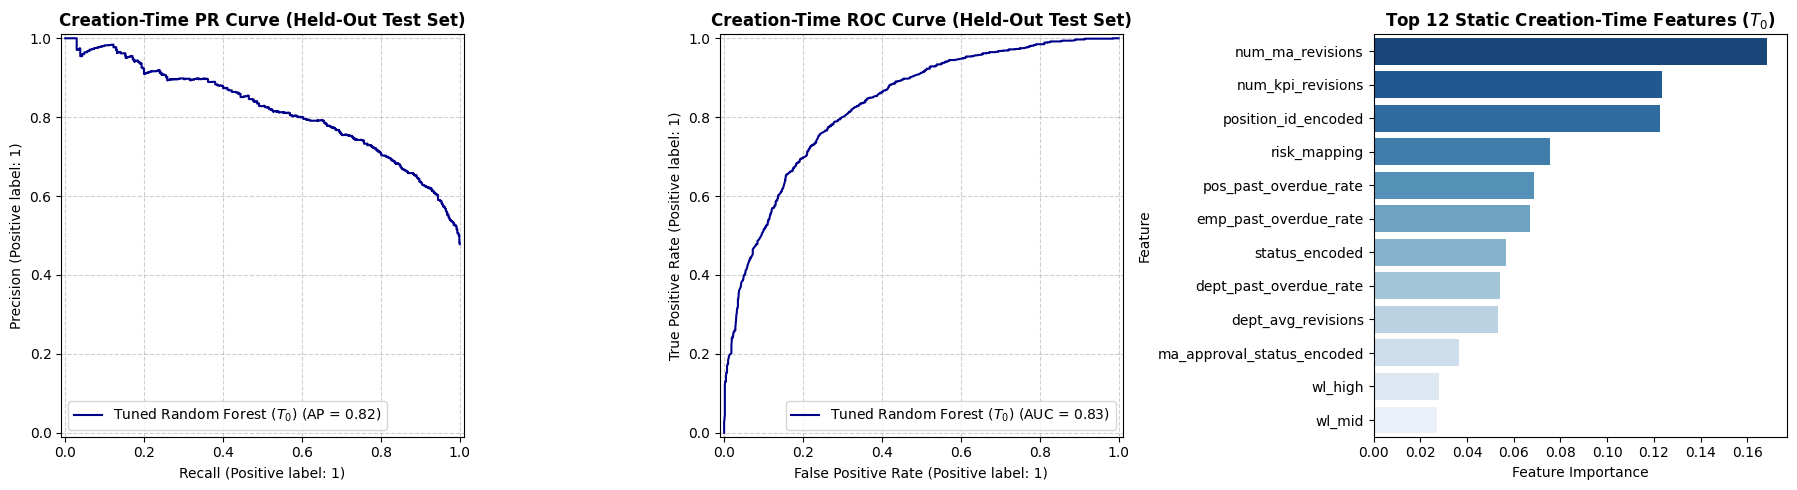

In [5]:
# Retrain best tuned Random Forest on combined Train+Val set
X_train_val_c = pd.concat([X_train_c, X_val_c])
y_train_val_c = pd.concat([y_train_c, y_val_c])

best_creation_model.fit(X_train_val_c, y_train_val_c)

y_train_val_probs_c = best_creation_model.predict_proba(X_train_val_c)[:, 1]
y_test_probs_c = best_creation_model.predict_proba(X_test_c)[:, 1]

train_val_pr_c = average_precision_score(y_train_val_c, y_train_val_probs_c)
test_pr_c = average_precision_score(y_test_c, y_test_probs_c)

print("=== CREATION-TIME ($T_0$) OVERFITTING & GENERALIZATION EVALUATION ===")
print(f"Train+Val PR-AUC : {train_val_pr_c:.4f}")
print(f"Held-Out Test PR-AUC : {test_pr_c:.4f}")
print(f"Generalization Gap   : {abs(train_val_pr_c - test_pr_c):.4f}")

print("\n=== FINAL CREATION-TIME TEST SET REPORT (Threshold = 0.50) ===")
print(classification_report(y_test_c, (y_test_probs_c >= 0.50).astype(int), target_names=['On-Time', 'Overdue']))

print("\n=== FINAL CREATION-TIME TEST SET REPORT (Threshold = 0.40) ===")
print(classification_report(y_test_c, (y_test_probs_c >= 0.40).astype(int), target_names=['On-Time', 'Overdue']))

# Visualizations: PR Curve, ROC Curve & Top Features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. PR Curve
PrecisionRecallDisplay.from_predictions(y_test_c, y_test_probs_c, name='Tuned Random Forest ($T_0$)', ax=axes[0], color='darkblue')
axes[0].set_title('Creation-Time PR Curve (Held-Out Test Set)', fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. ROC Curve
RocCurveDisplay.from_predictions(y_test_c, y_test_probs_c, name='Tuned Random Forest ($T_0$)', ax=axes[1], color='darkblue')
axes[1].set_title('Creation-Time ROC Curve (Held-Out Test Set)', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Top 12 Static Creation-Time Feature Importances
fi_c = pd.DataFrame({'Feature': X_c.columns, 'Importance': best_creation_model.feature_importances_}).sort_values(by='Importance', ascending=False).head(12)
sns.barplot(x='Importance', y='Feature', data=fi_c, ax=axes[2], palette='Blues_r')
axes[2].set_title('Top 12 Static Creation-Time Features ($T_0$)', fontweight='bold')
axes[2].set_xlabel('Feature Importance')

plt.tight_layout()
plt.show()
